# Klasifikasi Teks Sarkasme Bahasa Indonesia (IndoBERT-lite Base)

## Setup & Import
Sel ini menyiapkan library utama, seed, dan device yang dipakai sepanjang notebook.

In [1]:
import copy
import html
import json
import random
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, BertTokenizer, get_linear_schedule_with_warmup

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("gpu name:", torch.cuda.get_device_name(0))
    print("capability:", torch.cuda.get_device_capability(0))
    print("torch cuda version:", torch.version.cuda)
    print("arch list:", torch.cuda.get_arch_list())

sns.set_style("whitegrid")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

torch: 2.10.0+cu128
cuda available: True
gpu name: Tesla T4
capability: (7, 5)
torch cuda version: 12.8
arch list: ['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']
Device: cuda


## Hyperparameter

In [2]:
# Seed untuk reproducibility
SEED = 42

# Model configuration
MODEL_NAME = "indobenchmark/indobert-lite-base-p2"
CLASSIFIER_DROPOUT_PROB = 0.1
NUM_LABELS = 2

# Training configuration
MAX_LENGTH = 128
BATCH_SIZE = 16
LEARNING_RATE = 1e-6
WEIGHT_DECAY = 0.3
EPOCHS = 40

# Scheduler configuration
WARMUP_RATIO = 0.1

# Set seed
def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

# Display configuration
print("\n" + "="*60)
print("HYPERPARAMETER CONFIGURATION")
print("="*60)
print(f"Model:                {MODEL_NAME}")
print(f"Learning Rate:        {LEARNING_RATE}")
print(f"Weight Decay:         {WEIGHT_DECAY}")
print(f"Batch Size:           {BATCH_SIZE}")
print(f"Max Sequence Length:  {MAX_LENGTH}")
print(f"Number of Epochs:     {EPOCHS}")
print(f"Dropout Probability:  {CLASSIFIER_DROPOUT_PROB}")
print(f"Warmup Ratio:         {WARMUP_RATIO}")
print(f"Device:               {device}")
print("="*60 + "\n")


HYPERPARAMETER CONFIGURATION
Model:                indobenchmark/indobert-lite-base-p2
Learning Rate:        1e-06
Weight Decay:         0.3
Batch Size:           16
Max Sequence Length:  128
Number of Epochs:     40
Dropout Probability:  0.1
Warmup Ratio:         0.1
Device:               cuda



In [3]:
# ======================================
# PATHS & LABEL CONFIGURATION
# ======================================
REDDIT_DATA_DIR = Path("/kaggle/input/datasets/lathief137/indonesia-sarcastic/indonesia-sarcastic/reddit-dataset")
TWITTER_DATA_DIR = Path("/kaggle/input/datasets/lathief137/indonesia-sarcastic/indonesia-sarcastic/twitter-dataset")
LEXICON_PATH = Path("/kaggle/input/datasets/lathief137/colloquial-indonesian-lexicon/colloquial-indonesian-lexicon.csv")
PREPROCESS_OUTPUT_DIR = Path("/kaggle/working/preprocessed")
REDDIT_OUTPUT_DIR = PREPROCESS_OUTPUT_DIR / "reddit"
TWITTER_OUTPUT_DIR = PREPROCESS_OUTPUT_DIR / "twitter"
SAVE_PATH = Path("/kaggle/working/best_indobertlite_M5.pt")

REDDIT_INPUT_TEXT_COLUMN = "text"
TWITTER_INPUT_TEXT_COLUMN = "tweet"
LABEL_COLUMN = "label"
CLEAN_TEXT_COLUMN = "text_cleaned"
LOWER_TEXT_COLUMN = "text_lower"
NORMALIZED_TEXT_COLUMN = "text_normalized"
MODEL_TEXT_COLUMN = NORMALIZED_TEXT_COLUMN

LABEL_DISPLAY_NAMES = {
    0: "Nonsarkasme",
    1: "Sarkasme",
}

PREPROCESS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REDDIT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TWITTER_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Path configuration siap.")
print(f"  Reddit raw  : {REDDIT_DATA_DIR}")
print(f"  Twitter raw : {TWITTER_DATA_DIR}")
print(f"  Lexicon     : {LEXICON_PATH}")
print(f"  Reddit out  : {REDDIT_OUTPUT_DIR}")
print(f"  Twitter out : {TWITTER_OUTPUT_DIR}")
print(f"  Best model  : {SAVE_PATH}")

Path configuration siap.
  Reddit raw  : /kaggle/input/datasets/lathief137/indonesia-sarcastic/indonesia-sarcastic/reddit-dataset
  Twitter raw : /kaggle/input/datasets/lathief137/indonesia-sarcastic/indonesia-sarcastic/twitter-dataset
  Lexicon     : /kaggle/input/datasets/lathief137/colloquial-indonesian-lexicon/colloquial-indonesian-lexicon.csv
  Reddit out  : /kaggle/working/preprocessed/reddit
  Twitter out : /kaggle/working/preprocessed/twitter
  Best model  : /kaggle/working/best_indobertlite_M5.pt


## Preprocessing
Sel ini menjalankan preprocessing Reddit dan Twitter langsung dari raw dataset. Setiap split hanya menyimpan satu CSV final yang berisi kolom hasil tiap tahap preprocessing.

In [4]:
# ======================================
# SLANG LEXICON SETUP
# ======================================
lexicon_df = pd.read_csv(LEXICON_PATH)
lexicon_df["slang"] = lexicon_df["slang"].astype(str).str.lower()
lexicon_df["formal"] = lexicon_df["formal"].astype(str)
slang_dict = dict(zip(lexicon_df["slang"], lexicon_df["formal"]))

print(f"Jumlah entri dalam Colloquial Indonesian Lexicon: {len(slang_dict):,}")


def slang_normalize(text):
    if not isinstance(text, str):
        return ""

    words = text.split()
    normalized_words = []

    for word in words:
        if not re.search(r'\w', word):
            normalized_words.append(word)
            continue

        prefix = re.match(r'^\W+', word)
        suffix = re.search(r'\W+$', word)
        core = re.sub(r'^\W+|\W+$', '', word)

        if core in slang_dict:
            core = slang_dict[core]

        if prefix:
            core = prefix.group() + core
        if suffix:
            core = core + suffix.group()

        normalized_words.append(core)

    return " ".join(normalized_words)

Jumlah entri dalam Colloquial Indonesian Lexicon: 4,331


In [5]:
# ======================================
# REDDIT PREPROCESSING
# ======================================
def reddit_text_cleaning(text: str) -> str:
    if not isinstance(text, str):
        return ""

    # 1. Decode HTML entities (&amp; -> &, &lt; -> <, &gt; -> >)
    text = html.unescape(text)

    # 2. ROBUST MARKDOWN LINK HANDLING (sebelum placeholder dihapus)
    # [text](link) -> text
    text = re.sub(r'\[([^\]]+)\]\(.*?\)', r'\1', text)
    # [text](<link> -> text (malformed reddit, placeholder masih ada)
    text = re.sub(r'\[([^\]]+)\]\(<.*?>', r'\1', text)
    # hapus sisa "(link" atau "( link"
    text = re.sub(r'\(\s*link\s*\)?', '', text, flags=re.IGNORECASE)

    # 3. Hapus placeholder token
    text = re.sub(r'<username>|<hashtag>|<email>|<link>', '', text)

    # 4. Hapus reddit quote di awal (> atau >>)
    text = re.sub(r'^\s*>+\s?', '', text)

    # 5. Hapus markdown bold/italic (**text**, *text*)
    text = re.sub(r'\*\*(.*?)\*\*', r'\1', text)
    text = re.sub(r'\*(.*?)\*', r'\1', text)

    # 6. Hapus backslash
    text = text.replace("\\", " ")

    # 7. Hapus caret reddit formatting
    text = text.replace("^", " ")

    # 8. Hapus simbol non-linguistik (tapi simpan huruf, angka, tanda baca penting, dan &<>)
    text = re.sub(r'[^\w\s!?.,:;\'\"()\-/&<>]', ' ', text)

    # 9. Normalisasi huruf berulang (>=3 jadi 2)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # 10. Normalisasi tanda baca berulang (>=3 jadi 2)
    text = re.sub(r'([!?.,])\1{2,}', r'\1\1', text)

    # 11. Rapikan spasi
    text = re.sub(r'\s+', ' ', text).strip()

    return text

reddit_raw_files = {
    "train": REDDIT_DATA_DIR / "train.json",
    "validation": REDDIT_DATA_DIR / "validation.json",
    "test": REDDIT_DATA_DIR / "test.json",
}

reddit_preprocessed_frames = {}
for split_name, json_path in reddit_raw_files.items():
    if not json_path.exists():
        print(f"File tidak ditemukan: {json_path}")
        continue

    print(f"\nProcessing Reddit {split_name}: {json_path.name}")

    with open(json_path, "r", encoding="utf-8") as file_handle:
        data = json.load(file_handle)

    df = pd.DataFrame(data)

    if REDDIT_INPUT_TEXT_COLUMN not in df.columns:
        raise ValueError(f"Kolom '{REDDIT_INPUT_TEXT_COLUMN}' tidak ditemukan di {json_path}")
    if LABEL_COLUMN not in df.columns:
        raise ValueError(f"Kolom '{LABEL_COLUMN}' tidak ditemukan di {json_path}")

    df[LABEL_COLUMN] = pd.to_numeric(df[LABEL_COLUMN], errors="raise").astype(int)
    df[CLEAN_TEXT_COLUMN] = df[REDDIT_INPUT_TEXT_COLUMN].apply(reddit_text_cleaning)
    df[LOWER_TEXT_COLUMN] = df[CLEAN_TEXT_COLUMN].astype(str).str.lower()
    df[NORMALIZED_TEXT_COLUMN] = df[LOWER_TEXT_COLUMN].apply(slang_normalize)

    output_csv = REDDIT_OUTPUT_DIR / f"{split_name}_preprocessed.csv"
    df.to_csv(output_csv, index=False, encoding="utf-8-sig")

    print(f"   Saved: {output_csv}")
    print(f"   Total data: {len(df)}")
    print(f"   Kolom: {list(df.columns)}")

    reddit_preprocessed_frames[split_name] = df.copy()

print("\nReddit preprocessing selesai untuk train, validation, dan test.")

train_df = reddit_preprocessed_frames["train"][[NORMALIZED_TEXT_COLUMN, LABEL_COLUMN]].copy()
val_df = reddit_preprocessed_frames["validation"][[NORMALIZED_TEXT_COLUMN, LABEL_COLUMN]].copy()
reddit_test_df = reddit_preprocessed_frames["test"][[NORMALIZED_TEXT_COLUMN, LABEL_COLUMN]].copy()

print("\nTrain:", train_df.shape)
print("Validation:", val_df.shape)
print("Reddit test:", reddit_test_df.shape)


Processing Reddit train: train.json
   Saved: /kaggle/working/preprocessed/reddit/train_preprocessed.csv
   Total data: 9881
   Kolom: ['author', 'created_utc', 'score', 'permalink', 'subreddit', 'body', 'lang_fastText', 'label', 'text', 'text_cleaned', 'text_lower', 'text_normalized']

Processing Reddit validation: validation.json
   Saved: /kaggle/working/preprocessed/reddit/validation_preprocessed.csv
   Total data: 1411
   Kolom: ['author', 'created_utc', 'score', 'permalink', 'subreddit', 'body', 'lang_fastText', 'label', 'text', 'text_cleaned', 'text_lower', 'text_normalized']

Processing Reddit test: test.json
   Saved: /kaggle/working/preprocessed/reddit/test_preprocessed.csv
   Total data: 2824
   Kolom: ['author', 'created_utc', 'score', 'permalink', 'subreddit', 'body', 'lang_fastText', 'label', 'text', 'text_cleaned', 'text_lower', 'text_normalized']

Reddit preprocessing selesai untuk train, validation, dan test.

Train: (9881, 2)
Validation: (1411, 2)
Reddit test: (2824,

In [6]:
# ======================================
# TWITTER PREPROCESSING
# ======================================
def twitter_text_cleaning(text: str) -> str:
    if not isinstance(text, str):
        return ""

    # 0. Decode HTML entities (&amp; -> &, dll.)
    text = html.unescape(text)

    # 1. Hapus placeholder token Twitter
    text = re.sub(r'<username>|<hashtag>|<email>|<link>', '', text)

    # 2. Hapus RT (retweet marker)
    text = re.sub(r'\bRT\b', '', text)

    # 3. Hapus residual URL (pic.twitter, http, dll.)
    text = re.sub(r'pic\s*\.\s*twitter\s*\.\s*com/\S+', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # 4. Hapus literal unicode escape (\u2026, \ud83d, dll.) sebelum proses backslash
    text = re.sub(r'\\u[0-9a-fA-F]{4}', ' ', text)
    text = re.sub(r'\\U[0-9a-fA-F]{8}', ' ', text)

    # 5. Hapus semua karakter non-ASCII (emoji, mojibake, dll.)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)

    # 6. Hapus backslash
    text = text.replace("\\", " ")

    # 7. Hapus simbol non-linguistik (simpan huruf, angka, tanda baca penting, dan &)
    text = re.sub(r'[^\w\s!?.,:;\'\"()\-/&]', ' ', text)

    # 8. Normalisasi huruf berulang (>=3 jadi 2)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # 9. Normalisasi tanda baca berulang (>=3 jadi 2)
    text = re.sub(r'([!?.,])\1{2,}', r'\1\1', text)

    # 10. Rapikan spasi
    text = re.sub(r'\s+', ' ', text).strip()

    return text

twitter_raw_files = {
    "train": TWITTER_DATA_DIR / "train.csv",
    "validation": TWITTER_DATA_DIR / "validation.csv",
    "test": TWITTER_DATA_DIR / "test.csv",
}

twitter_preprocessed_frames = {}
for split_name, csv_path in twitter_raw_files.items():
    if not csv_path.exists():
        print(f"File tidak ditemukan: {csv_path}")
        continue

    print(f"\nProcessing Twitter {split_name}: {csv_path.name}")

    df = pd.read_csv(csv_path)

    if TWITTER_INPUT_TEXT_COLUMN not in df.columns:
        raise ValueError(f"Kolom '{TWITTER_INPUT_TEXT_COLUMN}' tidak ditemukan di {csv_path}")
    if LABEL_COLUMN not in df.columns:
        raise ValueError(f"Kolom '{LABEL_COLUMN}' tidak ditemukan di {csv_path}")

    df[LABEL_COLUMN] = pd.to_numeric(df[LABEL_COLUMN], errors="raise").astype(int)
    df[CLEAN_TEXT_COLUMN] = df[TWITTER_INPUT_TEXT_COLUMN].apply(twitter_text_cleaning)
    df[LOWER_TEXT_COLUMN] = df[CLEAN_TEXT_COLUMN].astype(str).str.lower()
    df[NORMALIZED_TEXT_COLUMN] = df[LOWER_TEXT_COLUMN].apply(slang_normalize)

    output_csv = TWITTER_OUTPUT_DIR / f"{split_name}_preprocessed.csv"
    df.to_csv(output_csv, index=False, encoding="utf-8-sig")

    print(f"   Saved: {output_csv}")
    print(f"   Total data: {len(df)}")
    print(f"   Kolom: {list(df.columns)}")

    twitter_preprocessed_frames[split_name] = df.copy()

print("\nTwitter preprocessing selesai untuk train, validation, dan test.")

twitter_train_df = twitter_preprocessed_frames["train"][[NORMALIZED_TEXT_COLUMN, LABEL_COLUMN]].copy()
twitter_val_df = twitter_preprocessed_frames["validation"][[NORMALIZED_TEXT_COLUMN, LABEL_COLUMN]].copy()
twitter_test_df = twitter_preprocessed_frames["test"][[NORMALIZED_TEXT_COLUMN, LABEL_COLUMN]].copy()

print("\nTwitter train:", twitter_train_df.shape)
print("Twitter validation:", twitter_val_df.shape)
print("Twitter test:", twitter_test_df.shape)


Processing Twitter train: train.csv
   Saved: /kaggle/working/preprocessed/twitter/train_preprocessed.csv
   Total data: 1878
   Kolom: ['tweet', 'label', 'text_cleaned', 'text_lower', 'text_normalized']

Processing Twitter validation: validation.csv
   Saved: /kaggle/working/preprocessed/twitter/validation_preprocessed.csv
   Total data: 268
   Kolom: ['tweet', 'label', 'text_cleaned', 'text_lower', 'text_normalized']

Processing Twitter test: test.csv
   Saved: /kaggle/working/preprocessed/twitter/test_preprocessed.csv
   Total data: 538
   Kolom: ['tweet', 'label', 'text_cleaned', 'text_lower', 'text_normalized']

Twitter preprocessing selesai untuk train, validation, dan test.

Twitter train: (1878, 2)
Twitter validation: (268, 2)
Twitter test: (538, 2)


## Contoh Data Sebelum dan Sesudah Preprocessing
Sel ini menampilkan 5 contoh untuk tiap kelas pada tiap dataset, sebelum preprocessing dan pada output final yang dipakai model.

In [7]:
def show_class_samples(df, text_column, label_column, dataset_name, stage_name, n_per_class=5):
    print(f"\n{dataset_name} - {stage_name}")

    for label_value in [0, 1]:
        label_name = LABEL_DISPLAY_NAMES[label_value]
        subset = df[df[label_column] == label_value].head(n_per_class)

        if subset.empty:
            print(f"Tidak ada data untuk kelas {label_value} ({label_name}).")
            continue

        display_df = subset[[label_column, text_column]].copy()
        display_df.insert(0, "label_name", label_name)
        display_df.insert(2, "stage", stage_name)
        display_df.columns = ["label_name", "label", "stage", "text"]
        display(display_df.reset_index(drop=True))


# ---------- REDDIT RAW ----------
reddit_raw_frames = {}
for split_name, json_path in reddit_raw_files.items():
    if not json_path.exists():
        continue

    with open(json_path, "r", encoding="utf-8") as file_handle:
        data = json.load(file_handle)

    temp_df = pd.DataFrame(data)
    temp_df[LABEL_COLUMN] = pd.to_numeric(temp_df[LABEL_COLUMN], errors="raise").astype(int)
    reddit_raw_frames[split_name] = temp_df

for split_name, raw_df in reddit_raw_frames.items():
    print(f"\n========== REDDIT {split_name.upper()} ==========")
    show_class_samples(raw_df, REDDIT_INPUT_TEXT_COLUMN, LABEL_COLUMN, f"Reddit {split_name}", "Sebelum Preprocessing")
    show_class_samples(reddit_preprocessed_frames[split_name], NORMALIZED_TEXT_COLUMN, LABEL_COLUMN, f"Reddit {split_name}", "Sesudah Preprocessing (Final)")


# ---------- TWITTER RAW ----------
twitter_raw_frames = {}
for split_name, csv_path in twitter_raw_files.items():
    if not csv_path.exists():
        continue

    temp_df = pd.read_csv(csv_path)
    temp_df[LABEL_COLUMN] = pd.to_numeric(temp_df[LABEL_COLUMN], errors="raise").astype(int)
    twitter_raw_frames[split_name] = temp_df

for split_name, raw_df in twitter_raw_frames.items():
    print(f"\n========== TWITTER {split_name.upper()} ==========")
    show_class_samples(raw_df, TWITTER_INPUT_TEXT_COLUMN, LABEL_COLUMN, f"Twitter {split_name}", "Sebelum Preprocessing")
    show_class_samples(twitter_preprocessed_frames[split_name], NORMALIZED_TEXT_COLUMN, LABEL_COLUMN, f"Twitter {split_name}", "Sesudah Preprocessing (Final)")


========== REDDIT TRAIN ==========

Reddit train - Sebelum Preprocessing


,label_name,label,stage,text
0,Nonsarkasme,0,Sebelum Preprocessing,Lo bilang chinese playing victim tapi lo gasad...
1,Nonsarkasme,0,Sebelum Preprocessing,"Kadang-kadang sampe aku mikir ""kayaknya buku g..."
2,Nonsarkasme,0,Sebelum Preprocessing,Bukanya berduka mlh buat konspirasi sendiri
3,Nonsarkasme,0,Sebelum Preprocessing,"Atta Halilintar pamer di youtube: ""Dasar pamer..."
4,Nonsarkasme,0,Sebelum Preprocessing,Pasti lokasinya di kalimantan


,label_name,label,stage,text
0,Sarkasme,1,Sebelum Preprocessing,"taat perintah tuhan : ""kalau ada razia mending..."
1,Sarkasme,1,Sebelum Preprocessing,Ini pasti hasil lobi dari paguyuban terapis2 d...
2,Sarkasme,1,Sebelum Preprocessing,"ah masih sedikit lah, gak sebanyak pulau jawa...."
3,Sarkasme,1,Sebelum Preprocessing,gaji DPR
4,Sarkasme,1,Sebelum Preprocessing,Jadi Johannes Widodo nama baptisnya Joko Widod...



Reddit train - Sesudah Preprocessing (Final)


,label_name,label,stage,text
0,Nonsarkasme,0,Sesudah Preprocessing (Final),lo bilang chinese playing victim tapi lo gasad...
1,Nonsarkasme,0,Sesudah Preprocessing (Final),"kadang-kadang sampai aku mikir ""kayaknya buku ..."
2,Nonsarkasme,0,Sesudah Preprocessing (Final),bukanya berduka malah buat konspirasi sendiri
3,Nonsarkasme,0,Sesudah Preprocessing (Final),"atta halilintar pamer di youtube: ""dasar pamer..."
4,Nonsarkasme,0,Sesudah Preprocessing (Final),pasti lokasinya di kalimantan


...

,label_name,label,stage,text
0,Nonsarkasme,0,Sebelum Preprocessing,Menag bicara sola celana cingkrang gak bisa ik...
1,Nonsarkasme,0,Sebelum Preprocessing,Koruptor dihukum berat bukannya dikasih kering...
2,Nonsarkasme,0,Sebelum Preprocessing,Belum jadi pemimpin udah bikin hoax gmn kalau ...
3,Nonsarkasme,0,Sebelum Preprocessing,Oi tolong lah itu yg pada demo suruh pulang . ...
4,Nonsarkasme,0,Sebelum Preprocessing,Ah tolol Ã¢Å¡ Ã¢Å¡ Ã¢Å¡ Ã¢Å¡ Ã¢Å¡ Ã¢Å¡ Ã¢Å¡ Ã¢...


,label_name,label,stage,text
0,Sarkasme,1,Sebelum Preprocessing,saraswati pintar sekali tida belajar dari peng...
1,Sarkasme,1,Sebelum Preprocessing,Karena JUJUR membuatku malu dan merasa bersala...
2,Sarkasme,1,Sebelum Preprocessing,Astagfirullah Medina Zein make narkoba ..saya ...
3,Sarkasme,1,Sebelum Preprocessing,bapak ngantornya di jalan tol saja bapak .. Ba...
4,Sarkasme,1,Sebelum Preprocessing,<username> Tolong dong bapakÂ² DPR kasih kulia...



Twitter test - Sesudah Preprocessing (Final)


,label_name,label,stage,text
0,Nonsarkasme,0,Sesudah Preprocessing (Final),menag bicara sola celana cingkrang enggak bisa...
1,Nonsarkasme,0,Sesudah Preprocessing (Final),koruptor dihukum berat bukannya dikasih kering...
2,Nonsarkasme,0,Sesudah Preprocessing (Final),belum jadi pemimpin sudah bikin hoax bagaimana...
3,Nonsarkasme,0,Sesudah Preprocessing (Final),oi tolong lah itu yang pada demo suruh pulang .
4,Nonsarkasme,0,Sesudah Preprocessing (Final),ah tolol


,label_name,label,stage,text
0,Sarkasme,1,Sesudah Preprocessing (Final),saraswati pintar sekali tida belajar dari peng...
1,Sarkasme,1,Sesudah Preprocessing (Final),karena jujur membuatku malu dan merasa bersala...
2,Sarkasme,1,Sesudah Preprocessing (Final),astagfirullah medina zein memakai narkoba ..sa...
3,Sarkasme,1,Sesudah Preprocessing (Final),bapak ngantornya di jalan tol saja bapak .. ba...
4,Sarkasme,1,Sesudah Preprocessing (Final),tolong dong bapak dpr kasih kuliah khusus dulu...


## EDA (Exploratory Data Analysis)

,split,label,count
0,reddit_test,Nonsarkasme,2118
1,reddit_test,Sarkasme,706
2,reddit_train,Nonsarkasme,7411
3,reddit_train,Sarkasme,2470
4,reddit_val,Nonsarkasme,1058
5,reddit_val,Sarkasme,353
6,twitter_test,Nonsarkasme,404
7,twitter_test,Sarkasme,134
8,twitter_train,Nonsarkasme,1408
9,twitter_train,Sarkasme,470


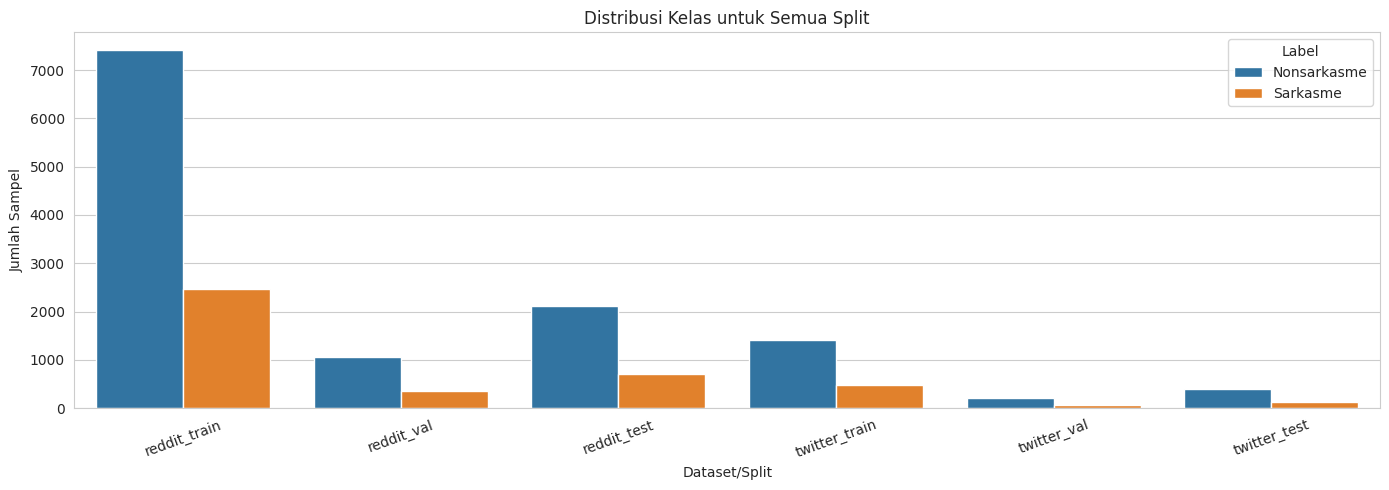

,count,mean,median,min,max
split,,,,,
reddit_test,2824,15.51,12.0,1,127
reddit_train,9881,15.23,11.0,0,183
reddit_val,1411,15.22,11.0,0,120
twitter_test,538,14.91,13.0,0,45
twitter_train,1878,15.87,14.0,0,55
twitter_val,268,16.39,15.0,1,49


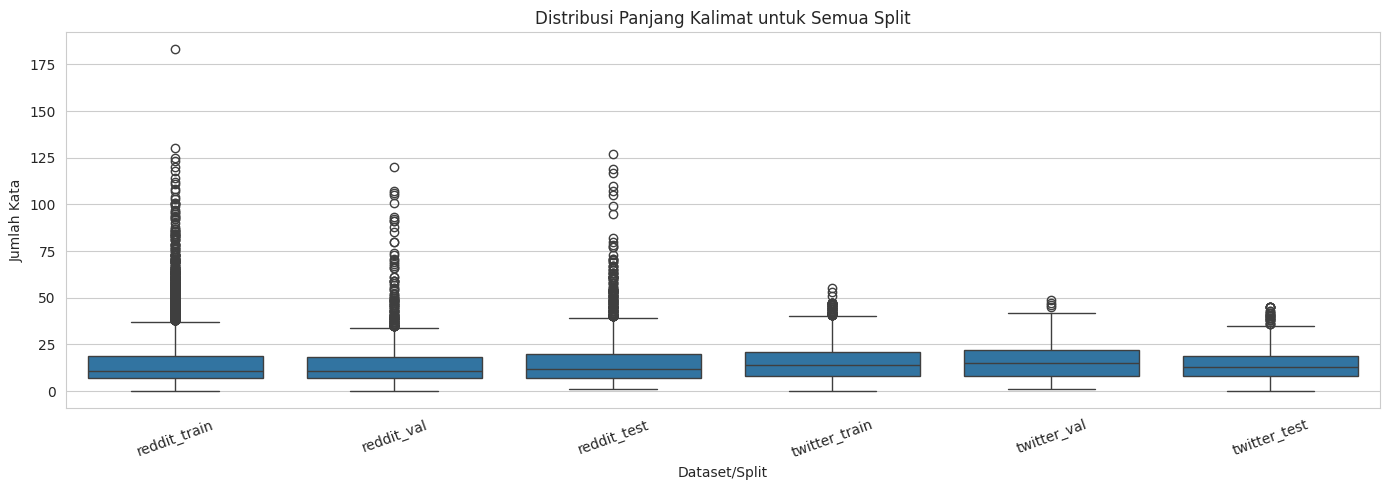

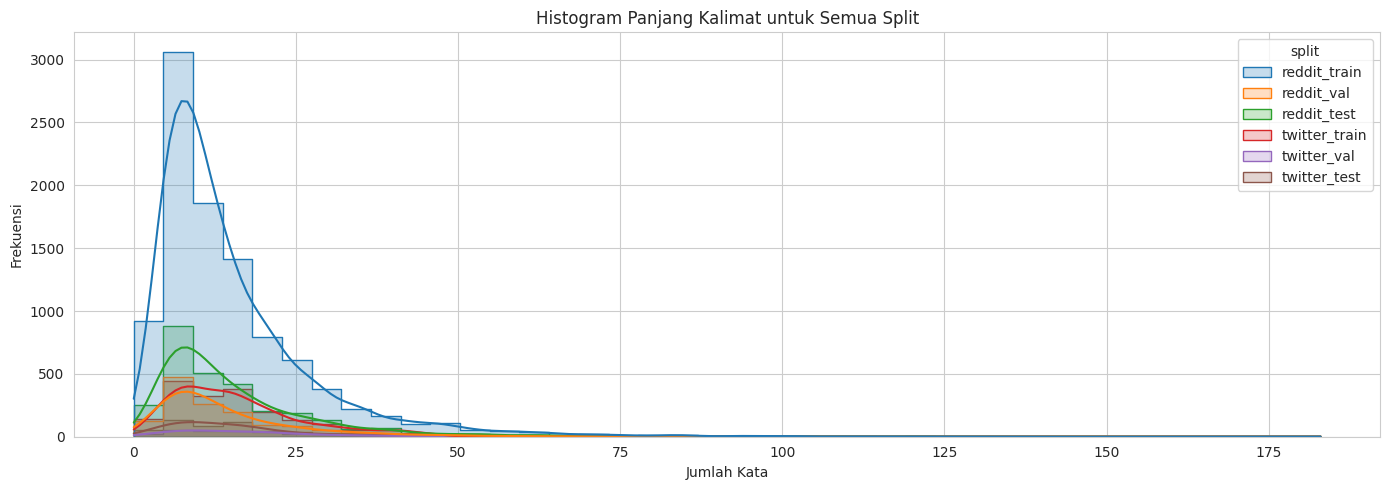

In [8]:
# EDA 1: Distribusi kelas untuk semua split
eda_frames = {
    "reddit_train": train_df,
    "reddit_val": val_df,
    "reddit_test": reddit_test_df,
    "twitter_train": twitter_train_df,
    "twitter_val": twitter_val_df,
    "twitter_test": twitter_test_df,
}

class_dist_rows = []
for split_name, df in eda_frames.items():
    vc = df[LABEL_COLUMN].value_counts().sort_index()
    for label_value, count in vc.items():
        label_name = LABEL_DISPLAY_NAMES.get(label_value, str(label_value))
        class_dist_rows.append({
            "split": split_name,
            "label": label_name,
            "count": int(count),
        })

class_dist_df = pd.DataFrame(class_dist_rows)
display(class_dist_df.sort_values(["split", "label"]).reset_index(drop=True))

plt.figure(figsize=(14, 5))
sns.barplot(data=class_dist_df, x="split", y="count", hue="label")
plt.title("Distribusi Kelas untuk Semua Split")
plt.xlabel("Dataset/Split")
plt.ylabel("Jumlah Sampel")
plt.xticks(rotation=20)
plt.legend(title="Label")
plt.tight_layout()
plt.show()

# EDA 2: Panjang kalimat untuk semua split
length_rows = []
for split_name, df in eda_frames.items():
    temp = df.copy()
    temp["length_words"] = temp[NORMALIZED_TEXT_COLUMN].str.split().str.len()
    length_rows.append(
        pd.DataFrame({
            "split": split_name,
            "length_words": temp["length_words"],
        })
    )

length_df = pd.concat(length_rows, ignore_index=True)

length_stats = (
    length_df.groupby("split")["length_words"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)
display(length_stats)

plt.figure(figsize=(14, 5))
sns.boxplot(data=length_df, x="split", y="length_words")
plt.title("Distribusi Panjang Kalimat untuk Semua Split")
plt.xlabel("Dataset/Split")
plt.ylabel("Jumlah Kata")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
sns.histplot(data=length_df, x="length_words", hue="split", bins=40, kde=True, element="step")
plt.title("Histogram Panjang Kalimat untuk Semua Split")
plt.xlabel("Jumlah Kata")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()

## Tokenizer & DataLoader
Sel ini menyiapkan tokenizer, dataset class, dan DataLoader untuk training/validasi/test.

In [9]:
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)


class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        encodings = tokenizer(
            list(texts),
            truncation=True,
            padding="max_length",
            max_length=max_length,
            return_tensors="pt",
        )
        self.input_ids = encodings["input_ids"]
        self.attention_mask = encodings["attention_mask"]
        self.labels = torch.tensor(list(labels), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels": self.labels[idx],
        }


train_dataset = TextDataset(train_df[MODEL_TEXT_COLUMN], train_df[LABEL_COLUMN], tokenizer, MAX_LENGTH)
val_dataset = TextDataset(val_df[MODEL_TEXT_COLUMN], val_df[LABEL_COLUMN], tokenizer, MAX_LENGTH)
reddit_test_dataset = TextDataset(reddit_test_df[MODEL_TEXT_COLUMN], reddit_test_df[LABEL_COLUMN], tokenizer, MAX_LENGTH)
twitter_test_dataset = TextDataset(twitter_test_df[MODEL_TEXT_COLUMN], twitter_test_df[LABEL_COLUMN], tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
reddit_test_loader = DataLoader(reddit_test_dataset, batch_size=BATCH_SIZE, shuffle=False)
twitter_test_loader = DataLoader(twitter_test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("DataLoader siap digunakan.")

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

DataLoader siap digunakan.


## Helper Functions
Fungsi-fungsi untuk training, evaluation, dan metrics calculation

In [10]:
def train_one_epoch(model, loader, optimizer, scheduler, criterion):
    model.train()
    total_loss = 0.0
    y_true = []
    y_pred = []

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    avg_loss = total_loss / len(loader)

    return avg_loss, np.array(y_true), np.array(y_pred)


def evaluate_one_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    y_true = []
    y_pred = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(logits, labels)
            preds = torch.argmax(logits, dim=1)

            total_loss += loss.item()
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    avg_loss = total_loss / len(loader)
    return avg_loss, np.array(y_true), np.array(y_pred)


def predict(model, loader):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(logits, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    return np.array(y_true), np.array(y_pred)


def get_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        pos_label=1,
        zero_division=0,
    )
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm,
    }

## Definisi Model

In [11]:
# Custom classification head: AutoModel encoder -> pooler_output -> dropout -> linear classifier.
class IndoBertLiteBase(nn.Module):
    def __init__(self, model_name, num_labels=2, classifier_dropout_prob=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(classifier_dropout_prob)
        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        # Get encoder outputs
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)

        # Use pooled output from ALBERT: CLS -> Linear -> Tanh
        pooled_output = outputs[1]

        # Apply classifier dropout
        pooled_output = self.dropout(pooled_output)

        # Linear classifier
        logits = self.classifier(pooled_output)
        return logits


model = IndoBertLiteBase(
    model_name=MODEL_NAME,
    num_labels=NUM_LABELS,
    classifier_dropout_prob=CLASSIFIER_DROPOUT_PROB
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Scheduler: linear warmup + linear decay (step per batch)
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print("\nModel initialized successfully")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/46.7M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/46.7M [00:00<?, ?B/s]


Model initialized successfully


## Training Loop

In [12]:
history = []
best_f1 = -1.0
best_state = None
best_epoch = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_true, train_pred = train_one_epoch(
        model,
        train_loader,
        optimizer,
        scheduler,
        criterion,
    )

    train_metrics = get_metrics(train_true, train_pred)

    val_loss, val_true, val_pred = evaluate_one_epoch(model, val_loader, criterion)
    val_metrics = get_metrics(val_true, val_pred)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_metrics["accuracy"],
        "train_precision": train_metrics["precision"],
        "train_recall": train_metrics["recall"],
        "train_f1": train_metrics["f1"],
        "val_loss": val_loss,
        "val_accuracy": val_metrics["accuracy"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
        "lr": optimizer.param_groups[0]["lr"],
    })

    print(
        f"Epoch {epoch:02d} | "
        f"lr={optimizer.param_groups[0]['lr']:.2e} | "
        f"train_loss={train_loss:.4f} | "
        f"train_acc={train_metrics['accuracy']:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_metrics['accuracy']:.4f} | "
        f"val_prec={val_metrics['precision']:.4f} | "
        f"val_rec={val_metrics['recall']:.4f} | "
        f"val_f1={val_metrics['f1']:.4f}"
    )

    if val_metrics["f1"] > best_f1:
        best_f1 = val_metrics["f1"]
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        best_val_true = val_true
        best_val_pred = val_pred
        torch.save(best_state, SAVE_PATH)
        print(f"  ✓ Best model saved! F1={best_f1:.4f} (Precision={val_metrics['precision']:.4f}, Recall={val_metrics['recall']:.4f})")

print("\n" + "="*60)
print(f"Training completed!")
print(f"Best F1 Score: {best_f1:.4f} at Epoch {best_epoch}")
print(f"Model saved to: {SAVE_PATH}")
print("="*60)

Epoch 01 | lr=2.50e-07 | train_loss=0.5625 | train_acc=0.7488 | val_loss=0.5483 | val_acc=0.7498 | val_prec=0.0000 | val_rec=0.0000 | val_f1=0.0000
  ✓ Best model saved! F1=0.0000 (Precision=0.0000, Recall=0.0000)
Epoch 02 | lr=5.00e-07 | train_loss=0.5267 | train_acc=0.7497 | val_loss=0.5255 | val_acc=0.7505 | val_prec=1.0000 | val_rec=0.0028 | val_f1=0.0056
  ✓ Best model saved! F1=0.0056 (Precision=1.0000, Recall=0.0028)
Epoch 03 | lr=7.50e-07 | train_loss=0.4885 | train_acc=0.7637 | val_loss=0.4880 | val_acc=0.7789 | val_prec=0.6952 | val_rec=0.2068 | val_f1=0.3188
  ✓ Best model saved! F1=0.3188 (Precision=0.6952, Recall=0.2068)
Epoch 04 | lr=1.00e-06 | train_loss=0.4492 | train_acc=0.7926 | val_loss=0.4734 | val_acc=0.7732 | val_prec=0.5517 | val_rec=0.4986 | val_f1=0.5238
  ✓ Best model saved! F1=0.5238 (Precision=0.5517, Recall=0.4986)
Epoch 05 | lr=9.72e-07 | train_loss=0.4220 | train_acc=0.8091 | val_loss=0.4607 | val_acc=0.7803 | val_prec=0.5700 | val_rec=0.4958 | val_f1=0.5

## Training History dan Visualisasi


Riwayat training:
    epoch  train_loss  train_accuracy  train_precision  train_recall  \
35     36    0.041097        0.991195         0.992966      0.971660   
36     37    0.039438        0.991499         0.993383      0.972470   
37     38    0.038424        0.992106         0.993807      0.974494   
38     39    0.037575        0.992308         0.993812      0.975304   
39     40    0.037125        0.993017         0.993830      0.978138   

    train_f1  val_loss  val_accuracy  val_precision  val_recall    val_f1  \
35  0.982198  0.944832      0.753366       0.507788    0.461756  0.483680   
36  0.982815  0.952679      0.756201       0.514196    0.461756  0.486567   
37  0.984056  0.960513      0.754784       0.510836    0.467422  0.488166   
38  0.984471  0.961741      0.754784       0.510903    0.464589  0.486647   
39  0.985921  0.963112      0.754075       0.509317    0.464589  0.485926   

              lr  
35  1.111111e-07  
36  8.333333e-08  
37  5.555556e-08  
38  2.777

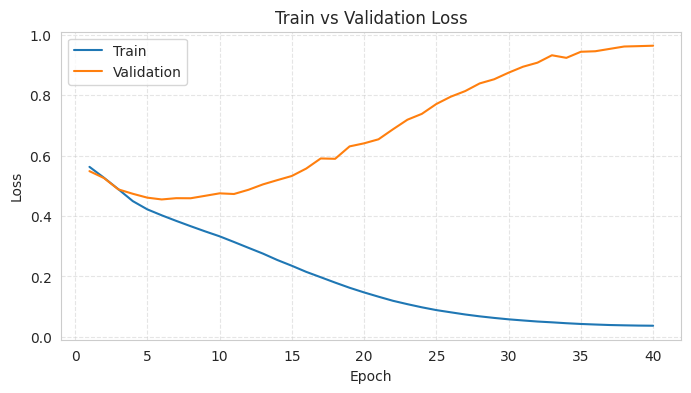

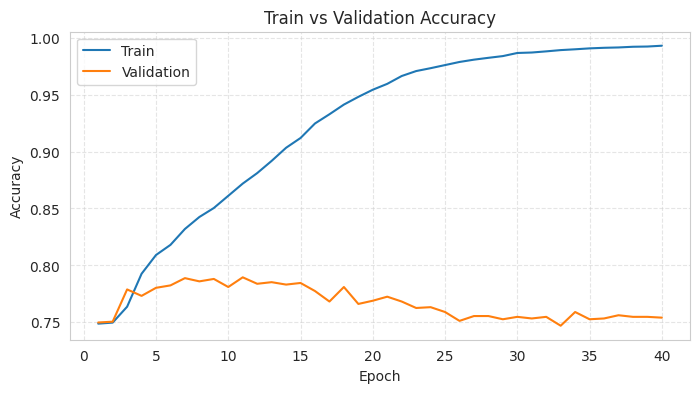

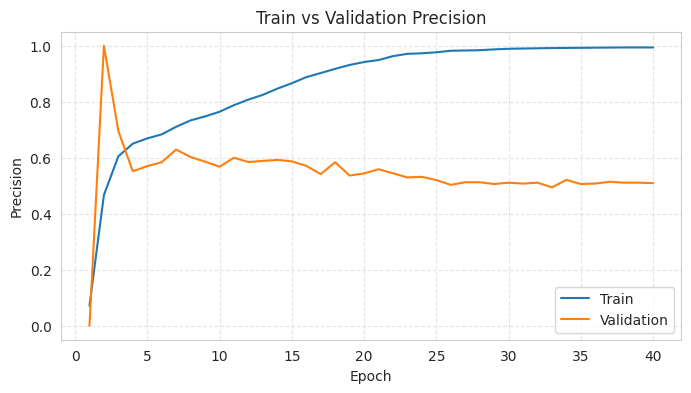

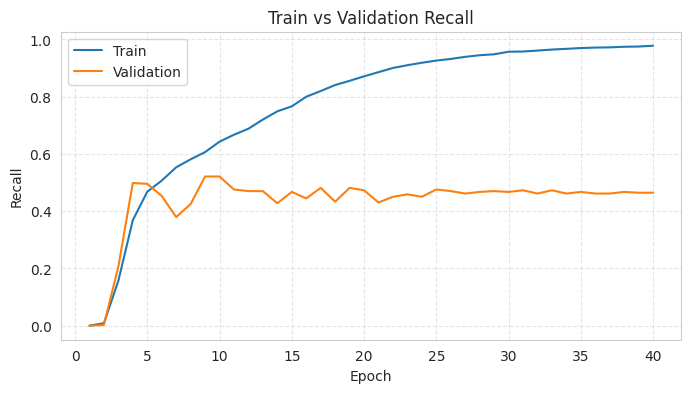

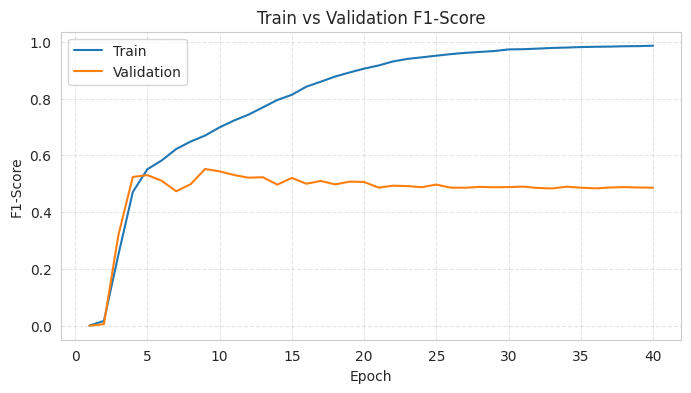

In [13]:
history_df = pd.DataFrame(history)
print("\nRiwayat training:")
print(history_df.tail())

# 1. Loss
plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# 2. Accuracy
plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_accuracy"], label="Train")
plt.plot(history_df["epoch"], history_df["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# 3. Precision
plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_precision"], label="Train")
plt.plot(history_df["epoch"], history_df["val_precision"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("Train vs Validation Precision")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# 4. Recall
plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_recall"], label="Train")
plt.plot(history_df["epoch"], history_df["val_recall"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Train vs Validation Recall")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# 5. F1-Score
plt.figure(figsize=(8, 4))
plt.plot(history_df["epoch"], history_df["train_f1"], label="Train")
plt.plot(history_df["epoch"], history_df["val_f1"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("F1-Score")
plt.title("Train vs Validation F1-Score")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


## Final Evaluation pada Test Sets


Validation Report - Best Epoch (9)
              precision    recall  f1-score   support

 Nonsarkasme     0.8459    0.8771    0.8613      1058
    Sarkasme     0.5860    0.5212    0.5517       353

    accuracy                         0.7881      1411
   macro avg     0.7160    0.6992    0.7065      1411
weighted avg     0.7809    0.7881    0.7838      1411



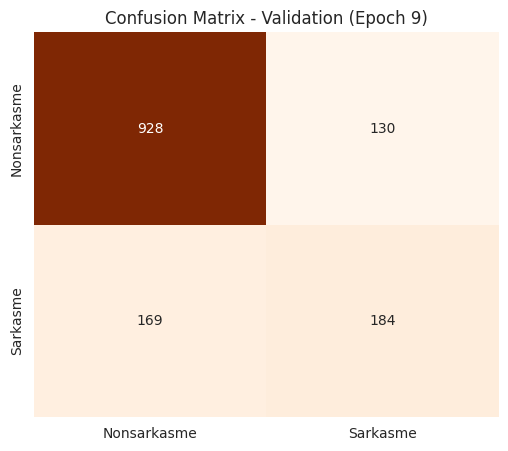


Best model loaded from: /kaggle/working/best_indobertlite_M5.pt

FINAL TEST RESULTS SUMMARY


,dataset,accuracy,precision,recall,f1
0,Reddit Test (In-Domain),0.786827,0.579755,0.535411,0.556701
1,Twitter Test (Cross-Domain),0.591078,0.308036,0.514925,0.385475



Classification Report - Reddit Test
              precision    recall  f1-score   support

 Nonsarkasme     0.8490    0.8706    0.8597      2118
    Sarkasme     0.5798    0.5354    0.5567       706

    accuracy                         0.7868      2824
   macro avg     0.7144    0.7030    0.7082      2824
weighted avg     0.7817    0.7868    0.7839      2824


Classification Report - Twitter Test
              precision    recall  f1-score   support

 Nonsarkasme     0.7930    0.6163    0.6936       404
    Sarkasme     0.3080    0.5149    0.3855       134

    accuracy                         0.5911       538
   macro avg     0.5505    0.5656    0.5395       538
weighted avg     0.6722    0.5911    0.6169       538



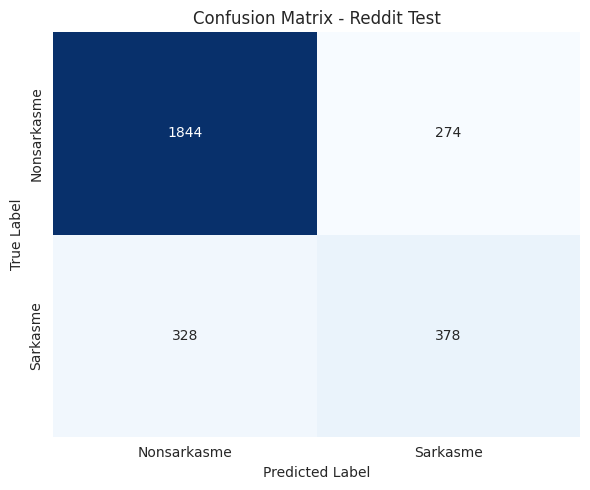

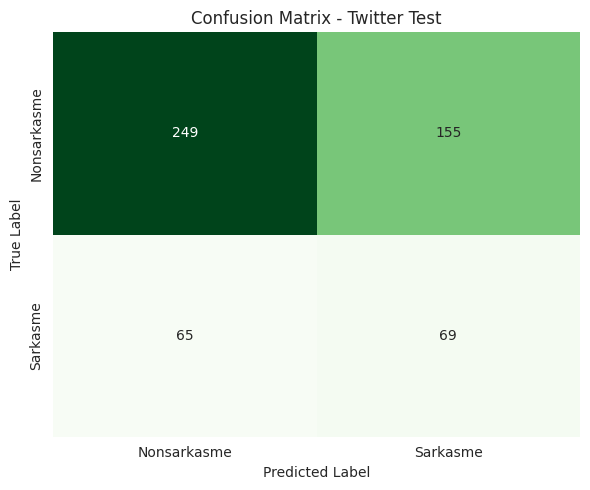

In [14]:
label_names = [LABEL_DISPLAY_NAMES[0], LABEL_DISPLAY_NAMES[1]]

try:
    best_val_true
except NameError:
    best_val_true = None

if best_val_true is not None:
    print("\n" + "="*70)
    print(f"Validation Report - Best Epoch ({best_epoch})")
    print("="*70)
    print(classification_report(
    best_val_true,
    best_val_pred,
    labels=[0, 1],
    target_names=label_names,
    digits=4,
    zero_division=0
))

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        confusion_matrix(best_val_true, best_val_pred, labels=[0, 1]),
        annot=True,
        fmt="d",
        cmap="Oranges",
        cbar=False,
        xticklabels=label_names,
        yticklabels=label_names,
    )
    plt.title(f"Confusion Matrix - Validation (Epoch {best_epoch})")
    plt.show()

# Load best model
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
print(f"\nBest model loaded from: {SAVE_PATH}")

# Evaluate on test sets
reddit_test_true, reddit_test_pred = predict(model, reddit_test_loader)
twitter_test_true, twitter_test_pred = predict(model, twitter_test_loader)

reddit_metrics = get_metrics(reddit_test_true, reddit_test_pred)
twitter_metrics = get_metrics(twitter_test_true, twitter_test_pred)

# Display results dalam DataFrame
results_data = [
    {
        "dataset": "Reddit Test (In-Domain)",
        "accuracy": reddit_metrics["accuracy"],
        "precision": reddit_metrics["precision"],
        "recall": reddit_metrics["recall"],
        "f1": reddit_metrics["f1"],
    },
    {
        "dataset": "Twitter Test (Cross-Domain)",
        "accuracy": twitter_metrics["accuracy"],
        "precision": twitter_metrics["precision"],
        "recall": twitter_metrics["recall"],
        "f1": twitter_metrics["f1"],
    },
]
results_df = pd.DataFrame(results_data)
print("\n" + "="*70)
print("FINAL TEST RESULTS SUMMARY")
print("="*70)
display(results_df)

# Classification Report - Reddit
print("\n" + "="*70)
print("Classification Report - Reddit Test")
print("="*70)
print(classification_report(reddit_test_true, reddit_test_pred, 
                          labels=[0, 1],
                          target_names=label_names,
                          digits=4,
                          zero_division=0))

# Classification Report - Twitter
print("\n" + "="*70)
print("Classification Report - Twitter Test")
print("="*70)
print(classification_report(twitter_test_true, twitter_test_pred,
                          labels=[0, 1],
                          target_names=label_names,
                          digits=4,
                          zero_division=0))

# Confusion Matrix - Reddit
cm_reddit = reddit_metrics["confusion_matrix"]
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_reddit,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=label_names,
    yticklabels=label_names,
)
plt.title("Confusion Matrix - Reddit Test")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Confusion Matrix - Twitter
cm_twitter = twitter_metrics["confusion_matrix"]
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_twitter,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False,
    xticklabels=label_names,
    yticklabels=label_names,
)
plt.title("Confusion Matrix - Twitter Test")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()